In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import glob
import re
from matplotlib.ticker import FormatStrFormatter
import matplotlib.ticker as ticker

In [2]:
genome=[30427671,19698289,23459830,18585056,26975502]
space=2000000
chr1=30427671 / 2 
chr2=30427671 + 19698289 / 2 + space
chr3=30427671 + 19698289 + 23459830 / 2 + space * 2
chr4=30427671 + 19698289 + 23459830 + 18585056 / 2 + space * 3
chr5=30427671 + 19698289 + 23459830 + 18585056 + 26975502 / 2 + space * 4

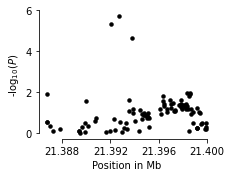

In [3]:
def parse(assoc):
    df = pd.read_table(assoc)
    df['P'] = -(np.log10(df['p_lrt']))
    df['P_bi'] = (np.log10(df['p_lrt']))
    space=2000000
    df['position'] = np.select([df['chr'] == 1, 
                                                df['chr'] == 2, 
                                                df['chr'] == 3, 
                                                df['chr'] == 4, 
                                                df['chr'] == 5],
                        [df['ps'], 
                        df['ps'] + 30427671 + space, 
                        df['ps'] + 30427671 + 19698289 + space * 2,
                        df['ps'] + 30427671 + 19698289 + 23459830 + space * 3,
                        df['ps'] + 30427671 + 19698289 + 23459830 + 18585056 + space * 4])
    
    return(df)

def major_formatter(x, pos):
    y = x /1000000
    return "%.3f" % y


start = 21391582-5000
end = 21395016+5000

gwas=parse('535_GWAS_Ionomics_filtered_AT5G52790.assoc.txt.gz')

zoom = gwas.loc[(gwas['chr'] == 5) &
                (gwas['ps'] > start) &
                (gwas['ps'] < end)]

cm = 1/2.54
fig = plt.figure(figsize=(8*cm,6*cm))
ax1=sns.scatterplot(x='ps',
                y='P',
                data=zoom,
                color='0',
                marker='o',
                s=15,
                linewidth=0.5,
                edgecolor='k',
                legend=False,
                zorder=2)
ax1.set_ylabel('-log$_{10}$($\itP$)',fontsize=10)
ax1.xaxis.set_major_formatter(major_formatter)
ax1.xaxis.set_major_locator(ticker.MultipleLocator(4000))
ax1.set_xlabel('Position in Mb',fontsize=10)
sns.despine(trim=True,ax=ax1)
# plt.savefig("FigS6a.pdf", format="pdf",bbox_inches="tight",facecolor="w")